# Задание 1. A/B-тестирование

 В ходе тестирования одной гипотезы целевой группе была предложена новая механика оплаты услуг на сайте, у контрольной группы оставалась базовая механика. В качестве задания необходимо проанализировать итоги эксперимента и сделать вывод, стоит ли запускать новую механику оплаты на всех пользователей.

In [42]:
# импортируем нужные библиотеки

import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import normaltest, levene
import seaborn as sns

In [2]:
# читаем наши данные

groups = pd.read_csv('groups.csv', sep=';')
groups_add = pd.read_csv('group_add.csv')
active_studs = pd.read_csv('active_studs.csv')
checks = pd.read_csv('checks.csv', sep=';')

### Предобработка данных:

In [3]:
groups = groups.rename(columns={groups.columns[0]: 'student_id', groups.columns[1]: 'group'})
groups.head()

,student_id,group
0,1489,B
1,1627,A
2,1768,B
3,1783,B
4,1794,A


Заметим, что группы очень несбалансированы. Это надо будет учитывать при интерпретации

In [5]:

groups.groupby('group').agg({'student_id': 'count'})

,student_id
group,
A,14671
B,59813


In [6]:
groups_add = groups_add.rename(columns={groups_add.columns[0]: 'student_id', groups_add.columns[1]: 'group'})
groups_add.head()

,student_id,group
0,5694584,B
1,5694830,B
2,5695057,B
3,5698872,B
4,5699067,B


In [7]:
groups_add.groupby('group').agg({'student_id': 'count'})

,student_id
group,
A,22
B,70


In [8]:
active_studs.head()

,student_id
0,581585
1,5723133
2,3276743
3,4238589
4,4475369


In [10]:
checks = checks.rename(columns={checks.columns[1]: 'revenue'})
checks.head()

,student_id,revenue
0,1627,990.0
1,3185,690.0
2,25973,690.0
3,26280,690.0
4,100300,990.0


### Агрегация по пользователям

In [11]:
checks_agg = checks.groupby('student_id').agg(revenue=('revenue','sum'), orders=('revenue','count')).reset_index()
active_studs_agg = active_studs.groupby('student_id').agg(active_days=('student_id','count')).reset_index()

In [12]:
df = groups.merge(checks_agg, on='student_id', how='left') \
.merge(groups_add, on='student_id', how='left').merge(active_studs_agg, on='student_id', how='left')

In [13]:
# собираем датафрейм со всеми показателями

df = df.fillna({'orders':0, 'revenue':0.0, 'active_days':0})
df = df.drop('group_y', axis=1)
df = df.rename(columns={'group_x': 'group'})
df.head()

,student_id,group,revenue,orders,active_days
0,1489,B,0.0,0.0,0.0
1,1627,A,990.0,1.0,1.0
2,1768,B,0.0,0.0,0.0
3,1783,B,0.0,0.0,0.0
4,1794,A,0.0,0.0,0.0


In [14]:
# количество пользователей с оплатой, но без активности

users_payment_no_activity = df[(df['revenue'] > 0) & (df['active_days'] == 0)]
users_payment_no_activity.shape[0]

149

### Анализируем метрики по группам

Какие метрики я смотрел и почему:

1. Conversion (конверсия в покупку). Ключ к пониманию, влияет ли новая механика на долю пользователей, которые покупают.
2. ARPU (average revenue per user). Учитывает объём покупателей и их платежи. Показывает влияния на доход на пользователя.
3. AOV (average order value). Показывает, если изменения влияют на средний чек покупателей.

In [15]:
metrics = df.groupby('group').agg(
    users_count=('student_id','count'),
    buyers=('orders', 'sum'),
    orders=('orders','sum'),
    revenue=('revenue','sum')
).reset_index() 

In [16]:
metrics['conversion'] = metrics['buyers'] / metrics['users_count']
metrics['arpu'] = metrics['revenue'] / metrics['users_count']
metrics['aov'] = metrics['revenue'] / metrics['buyers']

In [17]:
metrics

,group,users_count,buyers,orders,revenue,conversion,arpu,aov
0,A,14671,107.0,107.0,92096.0000,0.007293,6.277418,860.710280
1,B,59813,433.0,433.0,479330.0036,0.007239,8.013810,1106.997699


Делим пользователей на контрольную и тестовую группу для расчета метрик

In [18]:

groupA = df[df['group']=='A']
groupB = df[df['group']=='B']

In [19]:
# конверсия

conv_a = (groupA['orders']>0).sum()
conv_b = (groupB['orders']>0).sum()
n_a = groupA.shape[0]
n_b = groupB.shape[0]

### Проверим распределения на нормальность и равенство дисперсий

In [21]:
# метрики для проверки

arpu_A = groupA['revenue']
arpu_B = groupB['revenue']

aov_A = groupA[groupA['revenue'] > 0]['revenue']
aov_B = groupB[groupB['revenue'] > 0]['revenue']

Проверка нормальности с помощью теста Д'Агостино-Пирсона, т.к. размер выборок довольно большой

In [27]:
stat_arpu_A, p_arpu_A = normaltest(arpu_A)
stat_arpu_B, p_arpu_B = normaltest(arpu_B)
stat_aov_A, p_aov_A = normaltest(aov_A)
stat_aov_B, p_aov_B = normaltest(aov_B)

In [28]:
print("Значения p-value наших тестов:")
print(f"ARPU A: {p_arpu_A:.5f}, ARPU B: {p_arpu_B:.5f}")
print(f"AOV A : {p_aov_A:.5f}, AOV B : {p_aov_B:.5f}")

Значения p-value наших тестов:
ARPU A: 0.00000, ARPU B: 0.00000
AOV A : 0.00000, AOV B : 0.00000


P-value сильно меньше 0,05. Распределения явно ненормальные.

Проверяем однородность дисперсий с помощью теста Левена

In [29]:
stat_lev_ARPU, p_lev_ARPU = levene(arpu_A, arpu_B)
stat_lev_AOV, p_lev_AOV = levene(aov_A, aov_B)

In [30]:
print(f"ARPU: {p_lev_ARPU:.5f}")
print(f"AOV: {p_lev_AOV:.5f}")

ARPU: 0.08883
AOV: 0.04338


У показателя ARPU p-value > 0.05 --> мы не можем назвать дисперсии разными.
У показателя AOV p-value < 0.05 --> можно сделать вывод, что дисперсии различны.

### Проводим статистистические тесты.

1) Conversion. Тип данных бинарный (покупка есть или покупки нет). Мат. ожидание напрямую связано с успехами.  
   Используем z-тест для сравения долей.  
   Гипотезы:  
   H0: CR1 = CR2  
   H1: CR1 ≠ CR2  
   
2) ARPU. Много пользователей с нулевым revenue. Нормальность нарушена.  
   Используем bootstrap по средним значениям.  
   Гипотезы:  
   H0: mean(ARPU_A) = mean(ARPU_B)  
   H1: mean(ARPU_A) ≠ mean(ARPU_B)  
   
3) AOV. Аналогично ARPU - нет нормальности.  
   Используем bootstrap по средним значениям.  
   Гипотезы:  
   H0: mean(AOV_A) = mean(AOV_B)  
   H1: mean(AOV_A) ≠ mean(AOV_B)  

Проводим z-test для проверки гипотезы о статистической разницы в конверсии:

In [31]:
z_stat, pval = proportions_ztest([conv_b, conv_a], [n_b, n_a])

Для метрики ARPU я решил воспользоваться методом bootstrap:

In [35]:
def bootstrap_diff_mean(x, y, n_boot=5000, seed=42):
    rng = np.random.RandomState(seed)
    diffs = []
    for _ in range(n_boot):
        xs = rng.choice(x, len(x), replace=True)
        ys = rng.choice(y, len(y), replace=True)
        diffs.append(ys.mean() - xs.mean())
    return np.percentile(diffs, [2.5,97.5]), np.mean(diffs)

ci_arpu, diff_mean_arpu = bootstrap_diff_mean(arpu_A, arpu_B)

AOV среди покупателей:

In [34]:
aov_A = groupA[groupA['revenue'] > 0]['revenue'].values
aov_B = groupB[groupB['revenue'] > 0]['revenue'].values

ci_aov, diff_mean_aov = bootstrap_diff_mean(aov_A, aov_B)

Выводим значения метрик:

In [38]:
print(f"Conversion A: {conv_a/n_a:.4f}, B: {conv_b/n_b:.4f}, p-value={pval:.4f}")
print(f"ARPU diff (B-A): mean={diff_mean_arpu:.2f}, 95% CI={ci_arpu}")
print(f"AOV diff (B-A): mean={diff_mean_aov:.2f}, 95% CI={ci_aov}")

Conversion A: 0.0073, B: 0.0072, p-value=0.9448
ARPU diff (B-A): mean=1.74, 95% CI=[-0.18253296  3.55200041]
AOV diff (B-A): mean=247.83, 95% CI=[ 72.40309105 411.53285172]


# Визуализируем распределения

/var/folders/kd/_2qt2l6x10d9__g7c7vj_vq40000gn/T/ipykernel_6466/2902044809.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([groupA['revenue'], groupB['revenue']], labels=['A','B'])


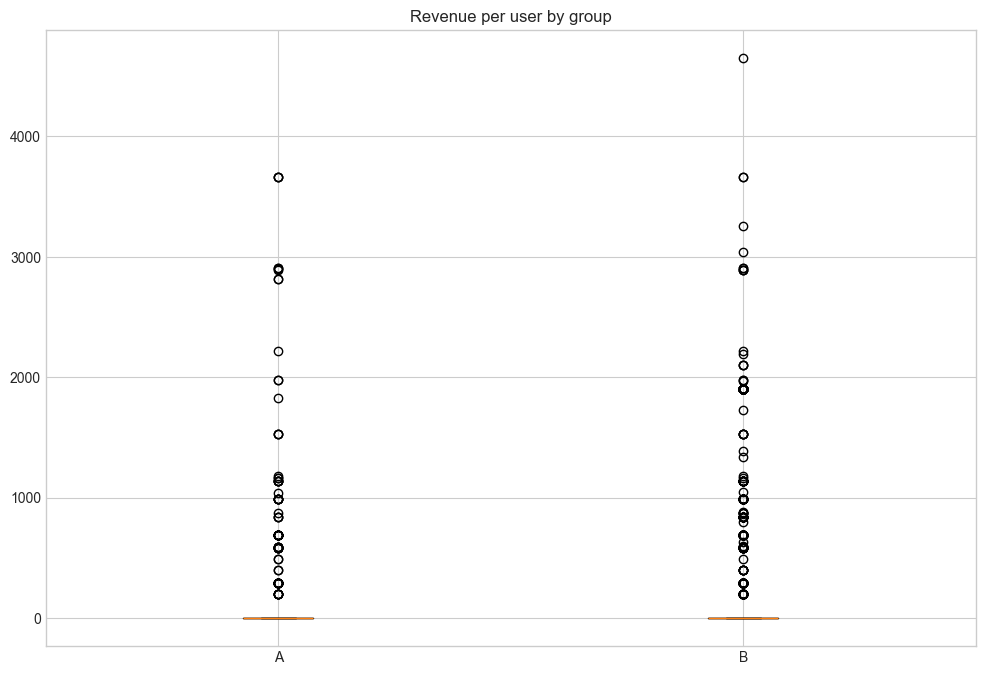

In [56]:
plt.figure(figsize=(12,8))
plt.boxplot([groupA['revenue'], groupB['revenue']], labels=['A','B'])
plt.title('Revenue per user by group')
plt.show()


Также добавим визуализацию ненулевых значений 

/var/folders/kd/_2qt2l6x10d9__g7c7vj_vq40000gn/T/ipykernel_6466/1789237865.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([revenueA_nonzero, revenueB_nonzero], labels=['A','B'])


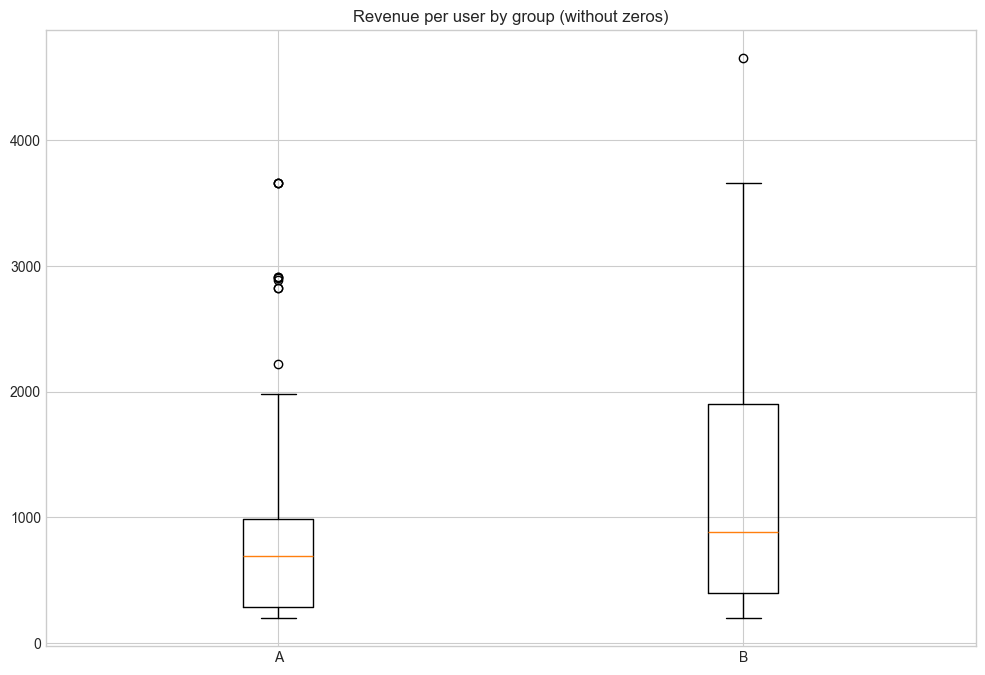

In [52]:
revenueA_nonzero = groupA['revenue'][groupA['revenue'] > 0]
revenueB_nonzero = groupB['revenue'][groupB['revenue'] > 0]

plt.figure(figsize=(12,8))
plt.boxplot([revenueA_nonzero, revenueB_nonzero], labels=['A','B'])
plt.title('Revenue per user by group (without zeros)')
plt.show()

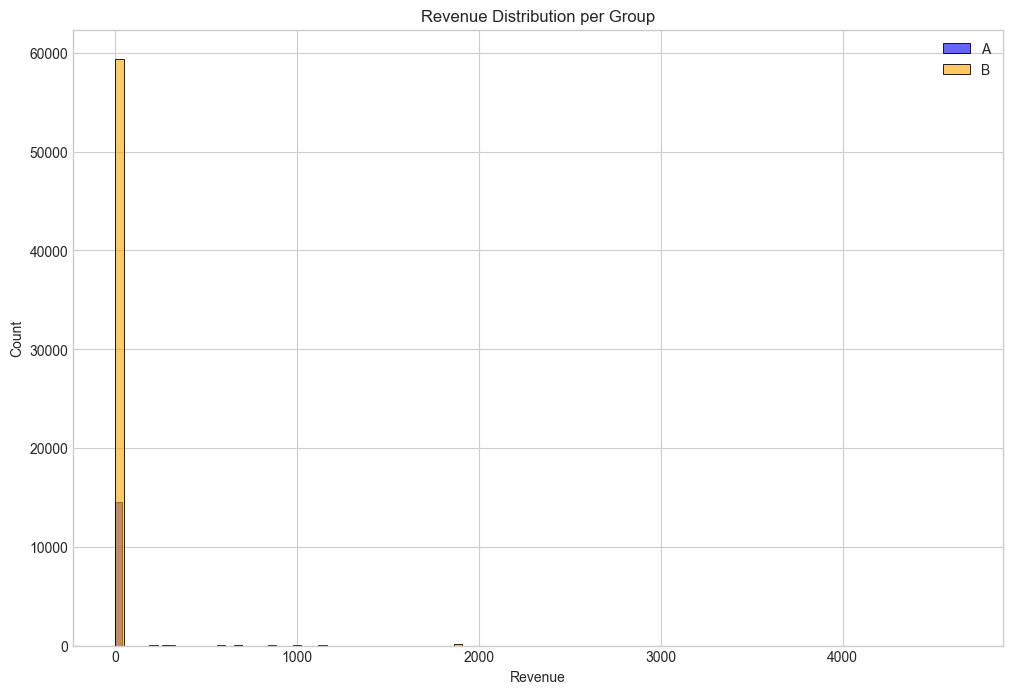

In [59]:

plt.figure(figsize=(12,8))

sns.histplot(groupA['revenue'], color='blue', label='A', bins=100, alpha=0.6)
sns.histplot(groupB['revenue'], color='orange', label='B', bins=100, alpha=0.6)

plt.xlabel('Revenue')
plt.ylabel('Count')
plt.title('Revenue Distribution per Group')
plt.legend()
plt.show()


Исходная гистограмма показывает распределение доходов пользователей, но сильно искажена нулями и выбросами. Для более наглядного сравнения групп построен KDE-график с логарифмической шкалой и без нулей. Такой график позволяет видеть концентрацию доходов, разброс и различия между группами, включая пользователей с высоким доходом.

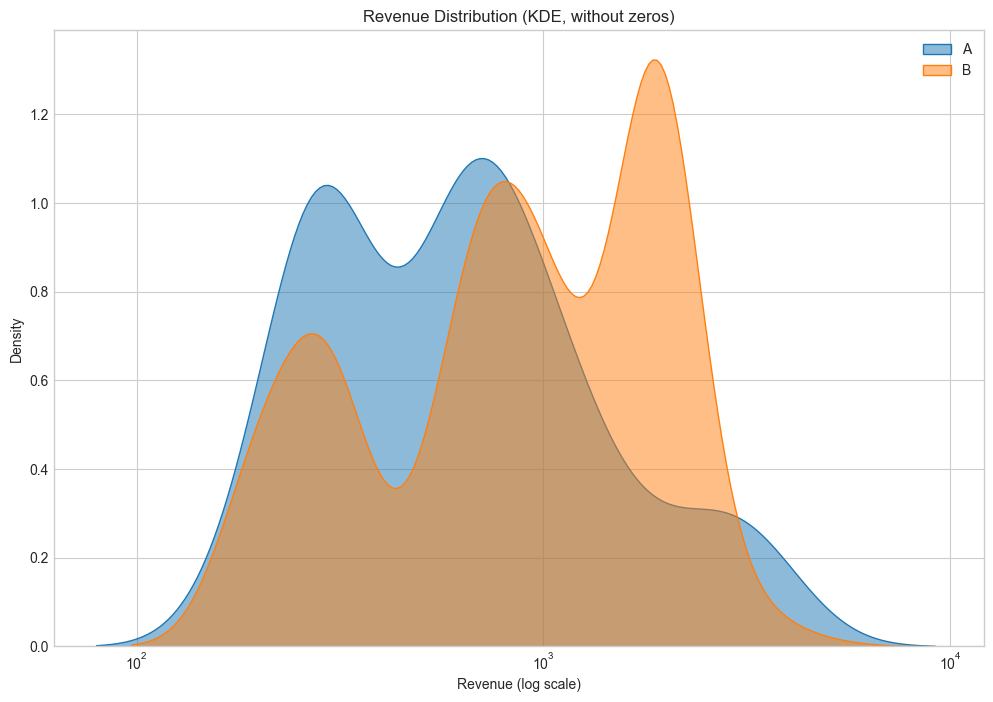

In [62]:
revenueA_nonzero = groupA['revenue'][groupA['revenue'] > 0]
revenueB_nonzero = groupB['revenue'][groupB['revenue'] > 0]

plt.figure(figsize=(12,8))

sns.kdeplot(revenueA_nonzero, fill=True, alpha=0.5, label='A', log_scale=True)
sns.kdeplot(revenueB_nonzero, fill=True, alpha=0.5, label='B', log_scale=True)

plt.xlabel('Revenue (log scale)')
plt.ylabel('Density')
plt.title('Revenue Distribution (KDE, without zeros)')
plt.legend()
plt.show()


## Выводы по результатам анализа:

1. Конверсия практически не изменилась. Различия оказались статистически незначимыми. P-value равен примерно 0,94. Можно сделать вывод, что новая механика не привела к увеличению доли покупателей.

2. ARPU вырос, но совершенно незначительно. 95% доверительный интервал включает 0. Общий доход на пользователя отличается мало и не проходит стандартный тест на значимость.

3. AOV среди покупателей растет статистически значимо. Мы уверены на 95%, что фича увеличивает средний чек. Увеличение AOV
напрямую повышает доход компании. 

4. Новая механика не увеличивает конверсию, но повышает средний чек у тех, кто уже покупает. Возможно, новая механика оплаты делает оплату более удобной или стимулирует лояльных клиентов тратить больше.

#### Рекомендации:

Я считаю, что запускать новую механику оплаты услуг на сайте на всех пользователей пока что не стоит. Следует провести дополнительное сегментное тестирование.

Например, рассмотреть запуск новой механики по сегментам, где рост AOV даёт наибольший профит. 

Можно провести дополнительные типы анализа: когортный анализ, распределение по дням, сравнение retention. 

#### Что нужно делать в первую очередь:

1. Провести целевой роллаут для определенных сегментов (либо провести еще один A/B тест, но с выровненными выборками в группах).

2. Разобраться с выбросами и источниками роста AOV.

3. При подтверждении эффекта в целевых сегментах - масштабировать.